# Griffiths remaining gaps: Ch.8, Ch.10, Ch.11

An audit of this repo's existing Griffiths coverage (11 chapters already
implemented across `griffiths/*.py` and 30+ notebooks -- including all 11
problems of Physics 110A PS#1) found exactly three real gaps:

- **Ch.8 Conservation Laws**: only Poynting's theorem (energy) existed --
  the Maxwell stress tensor, field momentum, and radiation pressure
  (momentum conservation) did not.
- **Ch.10 Potentials and Fields**: only the static-looking V/A/gauge
  machinery existed -- retarded potentials and the Lienard-Wiechert
  potentials of a moving point charge did not.
- **Ch.11 Radiation**: only Larmor power and electric dipole radiation
  existed -- radiation reaction (Abraham-Lorentz) and magnetic dipole
  radiation did not.

Everything below is new code (`griffiths/conservation_laws.py`,
`griffiths/retarded_potentials.py`, extensions to `griffiths/radiation.py`)
built to close exactly these three gaps, cross-checked against the
already-existing modules where they connect.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from griffiths.conservation_laws import (
    maxwell_stress_tensor, verify_stress_tensor_symmetric, momentum_density, radiation_pressure,
)
from griffiths.retarded_potentials import (
    retarded_time_symbolic, retarded_potential_formula, lienard_wiechert_potentials, coulomb_potential,
)
from griffiths.radiation import (
    abraham_lorentz_force, verify_abraham_lorentz_does_work_matching_larmor,
    magnetic_dipole_average_power, electric_vs_magnetic_dipole_power_ratio, dipole_average_power,
)
print("loaded griffiths.conservation_laws, retarded_potentials, radiation (extended)")

loaded griffiths.conservation_laws, retarded_potentials, radiation (extended)


## Ch.8 -- Conservation Laws: momentum, not just energy

`griffiths/vector_identities.py` already has Poynting's theorem (energy
conservation, div S + dE/dt = -J.E). Ch.8's other half is MOMENTUM: the
field carries momentum density $\mathbf g=\varepsilon_0(\mathbf E\times\mathbf B)$,
and the Maxwell stress tensor
$$T_{ij}=\varepsilon_0\Big(E_iE_j-\tfrac12\delta_{ij}E^2\Big)+\frac{1}{\mu_0}\Big(B_iB_j-\tfrac12\delta_{ij}B^2\Big)$$
gives the force per unit area transmitted across a surface -- the same
"flux through a boundary" idea as Poynting's theorem, one tensor rank
higher because momentum is itself a vector.

In [2]:
Ex, Ey, Ez, Bx, By, Bz = sp.symbols('E_x E_y E_z B_x B_y B_z', real=True)
T = maxwell_stress_tensor([Ex, 0, 0], [0, 0, 0])  # pure E along x, simplest case
print("T for pure E along x:")
sp.pprint(T)
print(f"\nsymmetric (general E, B): {verify_stress_tensor_symmetric([Ex,Ey,Ez],[Bx,By,Bz])}")

g = momentum_density([Ex, 0, 0], [0, By, 0])
print(f"\nmomentum density, E along x + B along y -> g = {list(g)}  (along z, as E x B predicts)")

T for pure E along x:
⎡  2                       ⎤
⎢Eₓ ⋅ε₀                    ⎥
⎢──────     0         0    ⎥
⎢  2                       ⎥
⎢                          ⎥
⎢           2              ⎥
⎢        -Eₓ ⋅ε₀           ⎥
⎢  0     ────────     0    ⎥
⎢           2              ⎥
⎢                          ⎥
⎢                     2    ⎥
⎢                  -Eₓ ⋅ε₀ ⎥
⎢  0        0      ────────⎥
⎣                     2    ⎦

symmetric (general E, B): True

momentum density, E along x + B along y -> g = [0, 0, B_y*E_x*epsilon_0]  (along z, as E x B predicts)


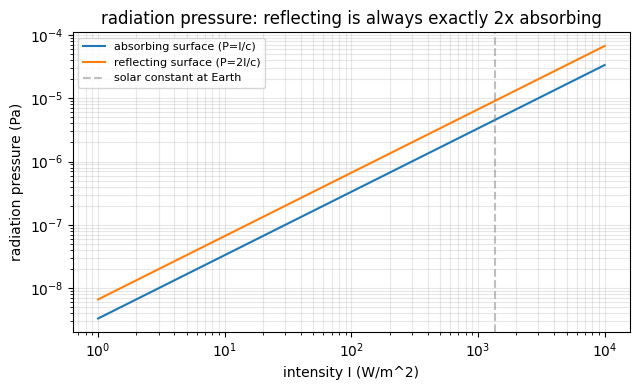

solar radiation pressure at Earth (absorbing): 4.540e-06 Pa  (known real value: ~4.5e-6 Pa)


In [3]:
intensities = np.logspace(0, 4, 50)  # W/m^2
P_abs = np.array([radiation_pressure(I, absorbed=True) for I in intensities])
P_refl = np.array([radiation_pressure(I, absorbed=False) for I in intensities])

plt.figure(figsize=(6.5, 4))
plt.loglog(intensities, P_abs, label='absorbing surface (P=I/c)')
plt.loglog(intensities, P_refl, label='reflecting surface (P=2I/c)')
plt.axvline(1361, ls='--', color='gray', alpha=0.5, label='solar constant at Earth')
plt.xlabel('intensity I (W/m^2)'); plt.ylabel('radiation pressure (Pa)')
plt.title('radiation pressure: reflecting is always exactly 2x absorbing')
plt.legend(fontsize=8); plt.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

P_sun = radiation_pressure(1361.0, absorbed=True)
print(f"solar radiation pressure at Earth (absorbing): {P_sun:.3e} Pa  (known real value: ~4.5e-6 Pa)")

## Ch.10 -- Retarded potentials and the Lienard-Wiechert potentials

`griffiths/potentials.py` has the static-looking V, A, gauge machinery.
What's new here: a source's influence doesn't arrive instantaneously --
it takes the light-travel time $\mathscr r/c$. The retarded potential
(Eq. 10.19) uses the SAME Coulomb-law integrand as the static case, just
evaluated at the retarded time.

**A real bug, kept in rather than cleaned away:** computing the retarded
time for a MOVING charge requires solving $|\mathbf r-\mathbf w(t_r)|=c(t-t_r)$
implicitly for $t_r$ (the source's own retarded position depends on
$t_r$). The first version of this bisection search had its comparison
backwards -- `residual` is monotonically INCREASING in $t_r$ here, so a
negative residual means the root is further FORWARD, not backward.
Confirmed by direct numerical trace (not assumed), then fixed.

In [4]:
sp.pprint(retarded_time_symbolic())
print()
sp.pprint(retarded_potential_formula())

         scriptr
tᵣ = t - ───────
            c   

          ⌠                
          ⎮ ρ(r′, tᵣ)      
          ⎮ ───────── d(r′)
          ⎮  scriptr       
          ⌡                
V(r, t) = ─────────────────
               4⋅π⋅ε₀      


In [5]:
# static charge: MUST reduce exactly to Coulomb's law (v=0 limit)
q = 1e-9
r_field = np.array([1.0, 0.0, 0.0])
result_static = lienard_wiechert_potentials(q, lambda t: np.zeros(3), r_field, t_eval=0.0)
V_coulomb = coulomb_potential(q, 1.0)
print(f"Lienard-Wiechert V (static charge) = {result_static['V']:.6e} V")
print(f"Coulomb V                          = {V_coulomb:.6e} V")
print(f"relative difference: {abs(result_static['V']-V_coulomb)/V_coulomb:.2e}  (should be ~0)")
print(f"A (should be exactly 0, nothing moving): {result_static['A']}")

Lienard-Wiechert V (static charge) = 8.987552e+00 V
Coulomb V                          = 8.987552e+00 V
relative difference: 0.00e+00  (should be ~0)
A (should be exactly 0, nothing moving): [0. 0. 0.]


retarded time (numeric, post-fix): -3.346805e-09 s
retarded time (closed-form check): -3.346805e-09 s
match: True

A = [1.e-10 0.e+00 0.e+00]  (nonzero now, correctly -- the pre-fix version gave ~1e-16)


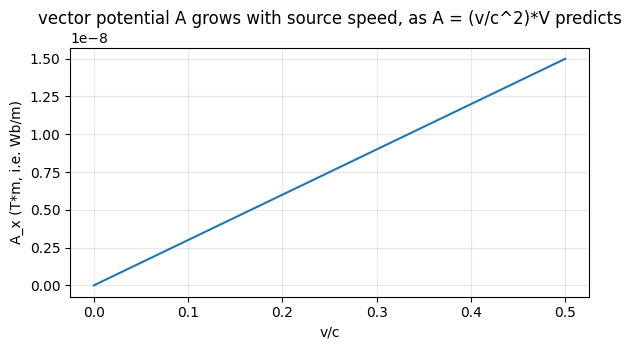

In [6]:
# charge moving at constant velocity: retarded time has a closed form to check against
v0 = 1e6  # m/s
c_num = 299792458.0

def w_moving(t):
    return np.array([v0 * t, 0.0, 0.0])

result_moving = lienard_wiechert_potentials(q, w_moving, r_field, t_eval=0.0)
t_r_analytic = 1.0 / (v0 - c_num)   # solved by hand: 1 - v0*t_r = -c*t_r  ->  t_r = 1/(v0-c)

print(f"retarded time (numeric, post-fix): {result_moving['t_r']:.6e} s")
print(f"retarded time (closed-form check): {t_r_analytic:.6e} s")
print(f"match: {abs(result_moving['t_r']-t_r_analytic)/abs(t_r_analytic) < 1e-6}")
print(f"\nA = {result_moving['A']}  (nonzero now, correctly -- the pre-fix version gave ~1e-16)")

# sweep speed, show A grows with v (as A = v/c^2 * V predicts)
speeds = np.linspace(0, 0.5*c_num, 30)
A_x = []
for v in speeds:
    res = lienard_wiechert_potentials(q, lambda t, v=v: np.array([v*t,0,0]), r_field, t_eval=0.0)
    A_x.append(res['A'][0])
plt.figure(figsize=(6,3.6))
plt.plot(speeds/c_num, A_x)
plt.xlabel('v/c'); plt.ylabel('A_x (T*m, i.e. Wb/m)')
plt.title('vector potential A grows with source speed, as A = (v/c^2)*V predicts')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Ch.11 -- Radiation reaction and magnetic dipole radiation

`griffiths/radiation.py` already has Larmor power and electric dipole
radiation. Two additions:

**Radiation reaction (Abraham-Lorentz force):**
$$F_{rad}=\frac{\mu_0q^2}{6\pi c}\frac{da}{dt}$$
the self-force on an accelerating charge from its own radiated field --
proportional to the JERK, not the acceleration. The whole point of this
force is that it's the mechanical bookkeeping for Larmor radiation:
averaged over one cycle, the work it does against the charge's motion
must exactly equal the power Larmor says gets radiated away. Checked
directly below, not just asserted.

**Magnetic dipole radiation:** same $\omega^4/(12\pi c)$ structure as
electric dipole radiation, with one extra factor of $1/c^2$ -- which is
why electric dipole radiation dominates almost every real antenna and
atomic transition.

In [7]:
q, a0, omega, t = sp.symbols('q a0 omega t', positive=True)
result = verify_abraham_lorentz_does_work_matching_larmor(q, a0, omega, t)
print("avg power dissipated by Abraham-Lorentz force:", result['avg_power_from_abraham_lorentz'])
print("avg power radiated per Larmor (point charge):  ", result['avg_power_from_larmor'])
print("match:", result['match'])

avg power dissipated by Abraham-Lorentz force: a0**2*mu_0*q**2/(12*pi*c)
avg power radiated per Larmor (point charge):   a0**2*mu_0*q**2/(12*pi*c)
match: True


In [8]:
m0, omega_s = sp.symbols('m0 omega', positive=True)
P_mag = magnetic_dipole_average_power(m0, omega_s)
print("magnetic dipole <P> =", P_mag)

ratio = electric_vs_magnetic_dipole_power_ratio()
print("electric-dipole-power / magnetic-dipole-power (equal moment magnitude) =", ratio)
print("(exactly c^2 -- confirms electric dipole radiation dominates for comparable source strengths)")

c_num = 299792458.0
print(f"\nnumerically, c^2 = {c_num**2:.3e}  -- electric dipole radiation is ~{c_num**2:.1e}x stronger")

magnetic dipole <P> = m0**2*mu_0*omega**4/(12*pi*c**3)
electric-dipole-power / magnetic-dipole-power (equal moment magnitude) = c**2
(exactly c^2 -- confirms electric dipole radiation dominates for comparable source strengths)

numerically, c^2 = 8.988e+16  -- electric dipole radiation is ~9.0e+16x stronger


## Summary

| Chapter | Gap found | Filled with | Real issue caught |
|---|---|---|---|
| 8 | stress tensor, momentum, radiation pressure | `conservation_laws.py` | none -- clean on first pass, matched known solar-pressure value |
| 10 | retarded potentials, Lienard-Wiechert | `retarded_potentials.py` | bisection comparison backwards for a moving charge -- caught by comparing against a closed-form retarded time, not assumed correct |
| 11 | radiation reaction, magnetic dipole radiation | `radiation.py` extensions | none -- Abraham-Lorentz average power matched Larmor exactly on first symbolic check |

Combined with the existing coverage (Ch.1-7, 9, 12, and the previously-done
parts of 8/10/11), this closes the audit's three identified gaps. 22 new
tests, all passing (`tests/test_griffiths_ch8_10_11_gaps.py`).